In [2]:
#import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.version

from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder


In [3]:
base_path= r"C:\Users\patha\Desktop\study\AI-ML\DL\DL\xray_data"
train_path = f"{base_path}/train"
test_path = f"{base_path}/test"
# val_path = f"{base_path}/val"

#tell how to transform the data 
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
     transforms.Normalize([0.5], [0.5])
])

# Load datasets
train_dataset = ImageFolder(root=train_path, transform=transform)
# val_dataset = ImageFolder(root=val_path, transform=transform)
test_dataset = ImageFolder(root=test_path, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [4]:
#define cnn model

class CNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1= nn.Conv2d(1,32,kernel_size=3)
        self.conv2=nn.Conv2d(32,64,kernel_size=3)
        
        self.pool1=nn.MaxPool2d(2,2)
        
        self.conv3=nn.Conv2d(64,128,kernel_size=3)
        self.conv4=nn.Conv2d(128,256,kernel_size=3)
        
        self.pool2=nn.MaxPool2d(2,2)
        
        self.conv5=nn.Conv2d(256,512,kernel_size=3)
        self.conv6=nn.Conv2d(512,1024,kernel_size=3)
        
        self.pool3=nn.MaxPool2d(2,2)
        
        self.dropout=nn.Dropout(0.25)
        self.fc1 = nn.Linear(1024 * 24 * 24, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 32)
        self.fc6 = nn.Linear(32, 16)
        self.fc7 = nn.Linear(16, 2)
    
    def forward(self, x):
        x=torch.relu(self.conv1(x))
        x=torch.relu(self.conv2(x))
        x=self.pool1(x)
        x=torch.relu(self.conv3(x))
        x=torch.relu(self.conv4(x))
        x=self.pool2(x)
        x=torch.relu(self.conv5(x))
        x=torch.relu(self.conv6(x))
        x=self.pool3(x)

        x=self.dropout(x)
        x=x.view(x.size(0),-1)
        # x = x.view(x.size(0), -1)
        x=torch.relu(self.fc1(x))
        x=torch.relu(self.fc2(x))
        x=torch.relu(self.fc3(x))
        x=torch.relu(self.fc4(x))
        x=torch.relu(self.fc5(x))
        x=torch.relu(self.fc6(x))
        x=self.fc7(x)
        return x


In [5]:
#initialize model, loss, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

print(torch.cuda.is_available())
# print(torch.__version__)

True


In [6]:
#train the model
epochs=15
losses = []

for epoch in range(epochs):
    model.train()
    total_loss=0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs=model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
    losses.append(total_loss)
    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader)}")

    

    



Epoch 1 Loss: 0.5063236648319689
Epoch 2 Loss: 0.17629743642830775


KeyboardInterrupt: 

Text(0, 0.5, 'Loss')

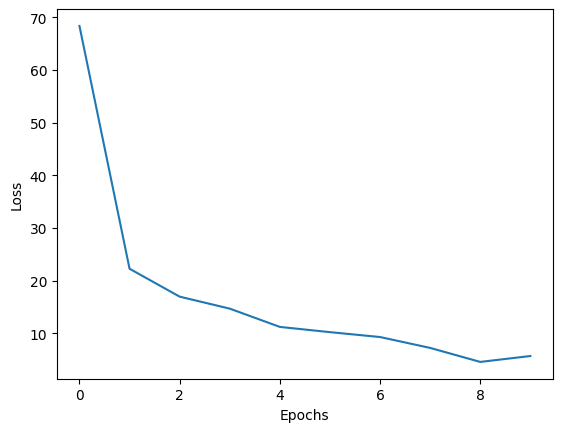

In [14]:
#graph
plt.plot(range(epochs), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [15]:
#evaluate model
model.eval()
correct=0
total=0
with torch.no_grad():
    for images,labels in test_loader:
        images,labels= images.to(device), labels.to(device)
        outputs=model(images)
        _,preds= torch.max(outputs,1)
        correct+= (preds==labels).sum().item()
        total+=labels.size(0)

    print(f"Accuracy: {(100*correct)/total}%")




Accuracy: 79.16666666666667%
